In [1]:
import numpy as numpy
import pandas as pd 


In [2]:
train_df = pd.read_csv('train.csv')
train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
test_df = pd.read_csv('test.csv')
test_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [4]:
train_df[['Crop_Type']].value_counts()

Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64

In [5]:
# pip install 

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_count_plot(df, col, hue=None, y_limit=None):
    # Set style and figure size
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    # Create the plot - hue will now be ignored if None
    ax = sns.countplot(data=df, x=col, hue=hue, palette='viridis' if hue else None)
    
    # Add data labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
    
    # Dynamic title based on whether hue is provided
    title = f"Count Plot of {col}"
    if hue:
        title += f" by {hue}"
    
    if y_limit:
        ax.set_ylim(0, y_limit)
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(col.replace('_', ' '), fontsize=12)
    ax.set_ylabel("Total Count", fontsize=12)
    
    # Only show legend if hue is present
    if hue:
        plt.legend(title=hue, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

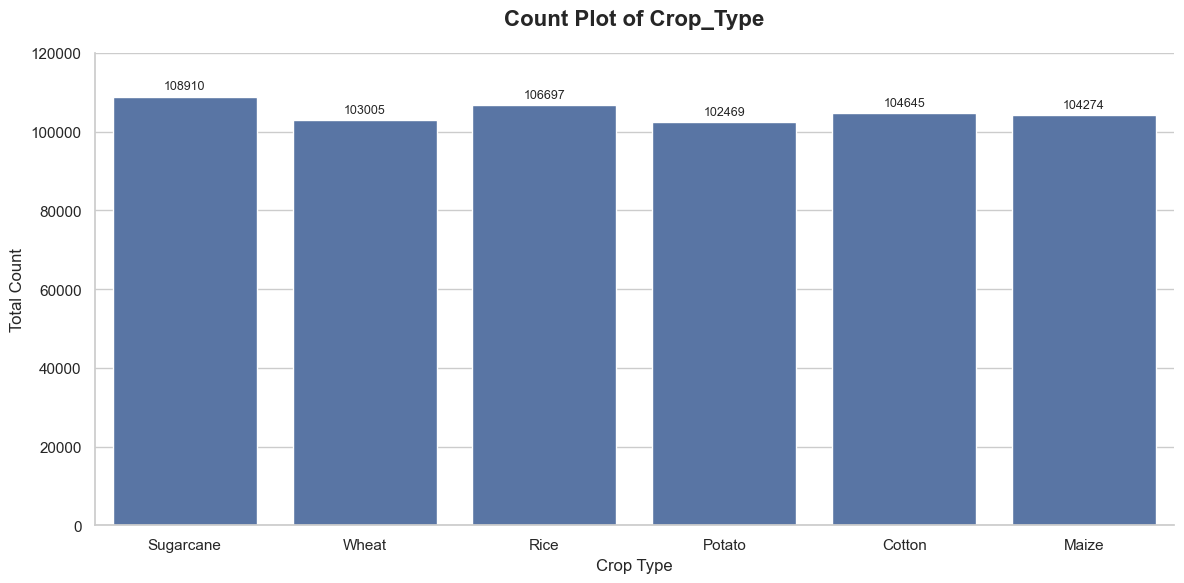

In [8]:
plot_count_plot(train_df, 'Crop_Type', y_limit=120000)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hist_plot(df, col, hue=None, y_limit=None, bins='auto', kde=True):
    # Set the visual theme
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    # Create the histogram
    # bins='auto' lets seaborn decide the optimal bar width
    # kde=True adds the smooth 'trend' line over the bars
    ax = sns.histplot(
        data=df, 
        x=col, 
        hue=hue, 
        kde=kde, 
        bins=bins,
        palette='viridis' if hue else None,
        element="step" if hue else "bars" # 'step' makes overlapping hues easier to see
    )
    
    # Set the Y-axis limit if you want to crop or add headroom
    if y_limit:
        ax.set_ylim(0, y_limit)
    
    # Formatting
    title = f"Histogram of {col}"
    if hue:
        title += f" by {hue}"
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(col.replace('_', ' '), fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    
    # Adjust legend if hue is active
    if hue:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# Example usage:
# plot_hist_plot(train_df, "Age", hue="Soil_Type", bins=30)

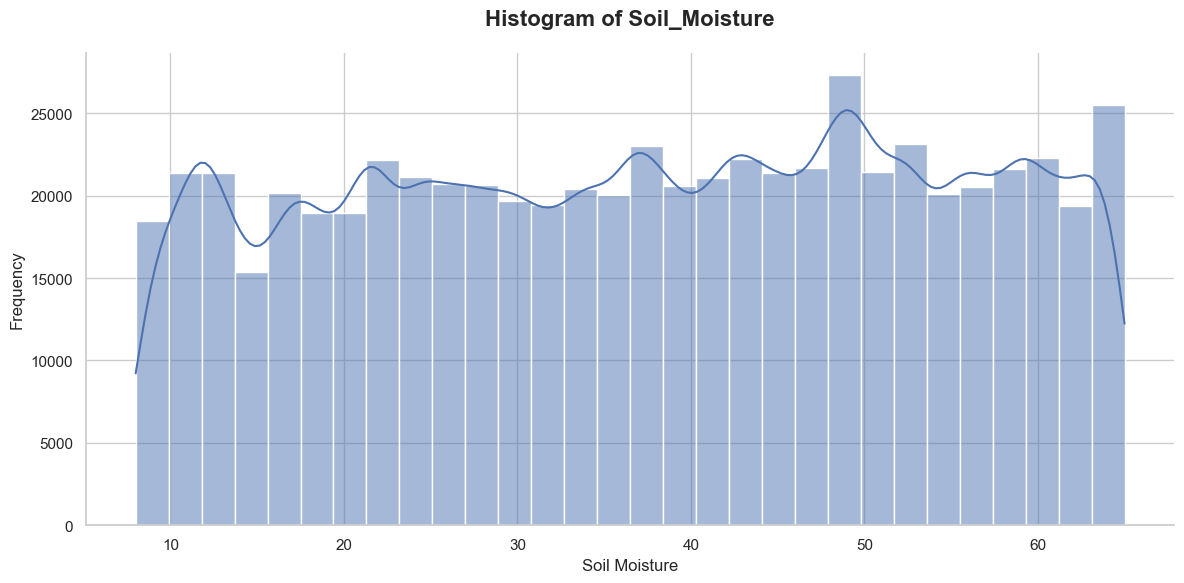

In [10]:
plot_hist_plot(train_df, "Soil_Moisture", bins=30)

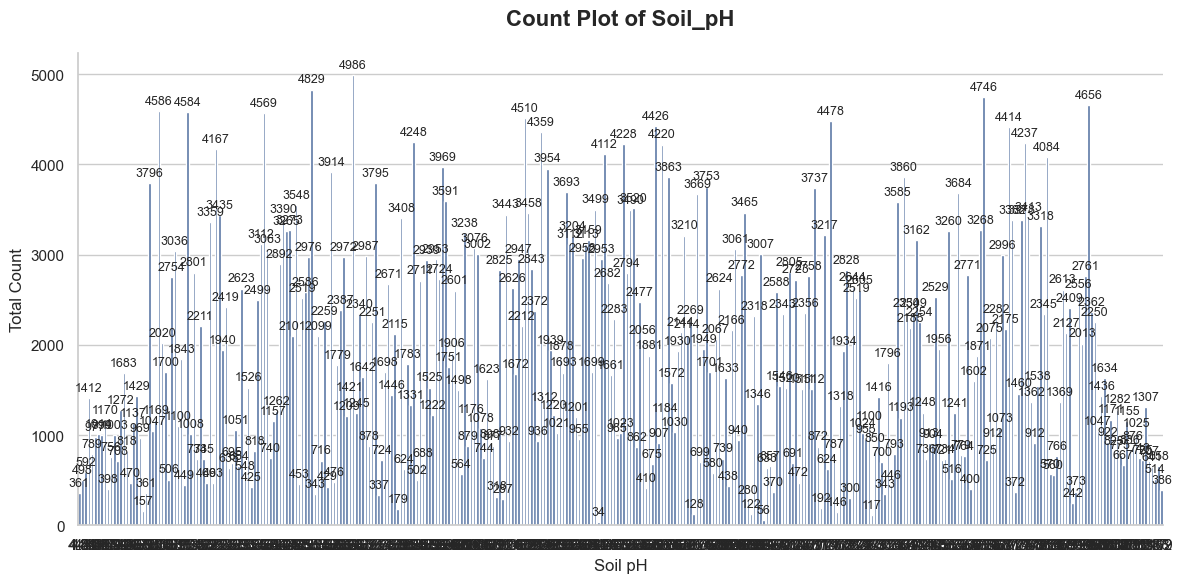

In [11]:
plot_count_plot(train_df, 'Soil_pH')

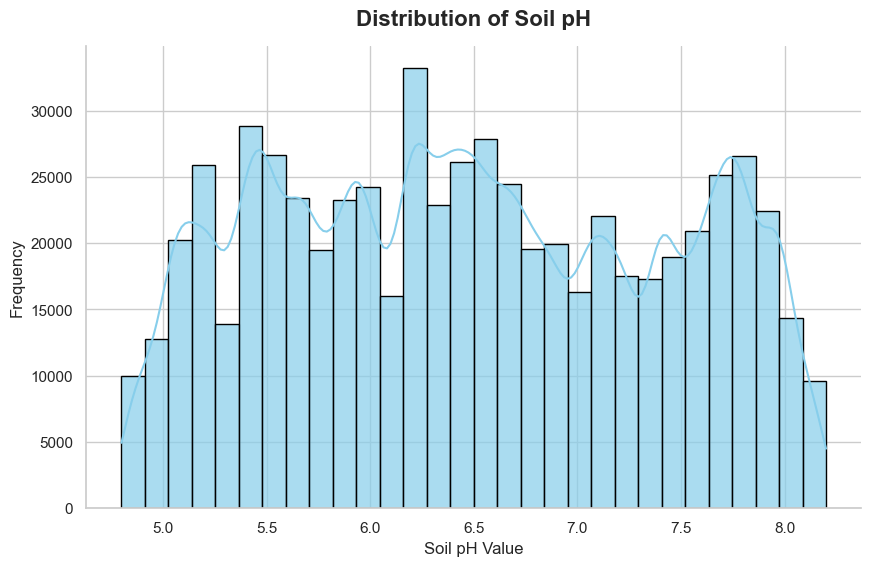

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Plotting with Seaborn for better aesthetics
ax = sns.histplot(
    data=train_df, 
    x='Soil_pH', 
    bins=30, 
    kde=True,          # Adds a smooth distribution line
    color='skyblue',   # A softer alternative to cyan
    edgecolor='black',
    alpha=0.7          # Slight transparency looks better
)

# Improve labels and title
plt.title('Distribution of Soil pH', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Soil pH Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Remove the top and right spines for a modern look
sns.despine()

plt.show()

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_all_numerical(df, cols_per_row=3, hue=None, size_per_plot=(5, 4)):
    # 1. Identify only numerical columns (integers and floats)
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    
    if not numeric_cols:
        print("No numerical columns found in the dataframe.")
        return

    # 2. Calculate grid dimensions
    num_plots = len(numeric_cols)
    rows = math.ceil(num_plots / cols_per_row)
    
    # 3. Initialize the figure
    fig, axes = plt.subplots(
        rows, 
        cols_per_row, 
        figsize=(cols_per_row * size_per_plot[0], rows * size_per_plot[1])
    )
    
    # Flatten axes array for easy iteration (handles 1D or 2D arrays)
    axes = axes.flatten()

    # 4. Loop through each column and create a plot
    for i, col in enumerate(numeric_cols):
        sns.histplot(
            data=df, 
            x=col, 
            hue=hue, 
            kde=True, 
            ax=axes[i], 
            palette='viridis' if hue else None,
            element="bars"
        )
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('') # Clear x-label to keep it clean; title says it all
        
    # 5. Hide any unused empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Usage:
# plot_all_numerical(train_df, hue='Soil_Type')

In [14]:
# plot_all_numerical(train_df)

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
num_df = train_df.select_dtypes(include=['number'])
num_df

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
0,0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,112.16
1,1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,47.16
2,2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,110.38
3,3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,53.85
4,4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,93.19
...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,4.35,118.36
629996,629996,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,12.97,40.75
629997,629997,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,13.58,2.62
629998,629998,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,5.00,0.79,90.00


In [17]:
num_df.drop(columns=['id'], inplace=True)
num_df.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,112.16
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,47.16
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,110.38
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,53.85
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,93.19


In [18]:
sc = StandardScaler()

scaler = StandardScaler()

# Set output to Pandas DataFrame
scaler.set_output(transform="pandas")

# Fit and transform the data
df_scaled = scaler.fit_transform(num_df)

print(df_scaled)

         Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0      -1.693757      -0.288482        0.238218                 1.370753   
1       0.647697       1.178814       -1.319979                 0.268182   
2      -0.859072      -0.585849       -0.308518                 1.139738   
3      -0.902432      -1.464516        1.112995                -0.918393   
4       1.601623       1.333298       -1.483999                -0.823887   
...          ...            ...             ...                      ...   
629995  0.062333      -1.456578        0.620933                 0.121173   
629996  0.593497       1.049365        0.101534                 0.635706   
629997  0.040653      -1.546338        0.019524                -1.432926   
629998 -0.598911       0.339225       -1.620683                 1.727775   
629999  0.582657      -0.118732        0.730280                -1.348921   

        Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0      

In [19]:
df_nums = pd.DataFrame(df_scaled)

In [20]:
# plot_all_numerical(df_nums)

In [21]:
cat_df = train_df.drop(columns=num_df.columns)
cat_df

,id,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region,Irrigation_Need
0,0,Loamy,Sugarcane,Sowing,Zaid,Drip,Rainwater,No,East,Low
1,1,Clay,Wheat,Vegetative,Kharif,Rainfed,River,Yes,South,Low
2,2,Clay,Rice,Vegetative,Kharif,Sprinkler,Reservoir,Yes,North,Low
3,3,Sandy,Wheat,Flowering,Kharif,Canal,River,Yes,South,Medium
4,4,Clay,Wheat,Sowing,Rabi,Canal,River,No,South,Low
...,...,...,...,...,...,...,...,...,...,...
629995,629995,Clay,Rice,Sowing,Kharif,Sprinkler,River,No,South,Medium
629996,629996,Clay,Sugarcane,Vegetative,Kharif,Drip,Groundwater,Yes,Central,Medium
629997,629997,Clay,Potato,Vegetative,Zaid,Canal,Reservoir,Yes,South,High
629998,629998,Clay,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,Yes,East,Low


In [22]:
cat_df['Crop_Growth_Stage'].value_counts()

Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64

In [23]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

enc = OneHotEncoder(sparse_output=False)


In [24]:
cat_df.drop(['id', 'Irrigation_Need'],axis=1, inplace=True)
cat_df.head()

,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region
0,Loamy,Sugarcane,Sowing,Zaid,Drip,Rainwater,No,East
1,Clay,Wheat,Vegetative,Kharif,Rainfed,River,Yes,South
2,Clay,Rice,Vegetative,Kharif,Sprinkler,Reservoir,Yes,North
3,Sandy,Wheat,Flowering,Kharif,Canal,River,Yes,South
4,Clay,Wheat,Sowing,Rabi,Canal,River,No,South


In [25]:
# 1. Fit and Transform the FEATURES
# This creates the 32-column array
feature_data = enc.fit_transform(cat_df)

# 2. Create the DataFrame using that feature data
# Now the 32 columns of data will match the 32 column names
encoded_df = pd.DataFrame(
    feature_data, 
    columns=enc.get_feature_names_out()
)

# 3. Handle your Target separately (DO NOT One-Hot encode it)
# Keep your LabelEncoded target as its own Series/Array
# y = label_encoder.fit_transform(df['Irrigation_Need'])

In [26]:
encoded_df 

,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Potato,Crop_Type_Rice,Crop_Type_Sugarcane,Crop_Type_Wheat,...,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
629996,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
629997,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
629998,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [27]:
le = LabelEncoder()
y = le.fit_transform(train_df['Irrigation_Need'])

# Check the mapping
print(le.classes_)        # e.g., ['No' 'Yes']
print(y[:5])              # e.g., [0 1 0 1 1]

['High' 'Low' 'Medium']
[1 1 1 2 1]


In [28]:
label_df = pd.DataFrame(y)
label_df.head()

,0
0,1
1,1
2,1
3,2
4,1


In [29]:
import numpy as np

In [30]:
X = np.hstack([df_scaled.values, encoded_df.values])
print("Training X shape:", X.shape)
print("y shape:", y.shape)

Training X shape: (630000, 43)
y shape: (630000,)


In [31]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── STEP 2: Preprocess test_df the SAME way ───────────────────────────

# Numerical: use the SAME scaler (already fitted on train)
test_num = test_df.select_dtypes(include=['number']).drop(columns=['id'])
X_test_num = scaler.transform(test_num)           # transform only, NOT fit_transform

# Categorical: use the SAME encoder (already fitted on train)
test_cat = test_df.drop(columns=test_num.columns)
test_cat.drop(['id'], axis=1, inplace=True)       # no Irrigation_Need in test
X_test_cat = enc.transform(test_cat)              # transform only, NOT fit_transform

X_test = np.hstack([X_test_num, X_test_cat])
print("Test X shape:", X_test)

Test X shape: [[-0.13278775 -0.67866121 -0.90992681 ...  0.          0.
   1.        ]
 [-0.66395094 -1.67456589  0.7029436  ...  0.          1.
   0.        ]
 [-0.28454866 -0.65667925  0.10153429 ...  0.          0.
   0.        ]
 ...
 [ 1.46070181 -1.60495637  1.74174149 ...  0.          0.
   0.        ]
 [ 0.69105719 -1.65624759  1.08565861 ...  0.          0.
   0.        ]
 [ 0.13821388 -0.75376622  1.33168969 ...  0.          1.
   0.        ]]


In [32]:
# ── STEP 3: Train & compare models on training data ───────────────────

models = {
    # "Logistic Regression" : LogisticRegression(max_iter=1000),
    # "Decision Tree"       : DecisionTreeClassifier(),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42),
    "XGBoost"             : XGBClassifier(eval_metric='mlogloss', random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X, y)
    y_train_pred = model.predict(X)
    trained_models[name] = model
    
    results.append({
        "Model"     : name,
        "Train Acc" : round(accuracy_score(y, y_train_pred), 4),
        "F1 (macro)": round(f1_score(y, y_train_pred, average='macro'), 4),
    })

results_df = pd.DataFrame(results).sort_values("F1 (macro)", ascending=False)
print(results_df.to_string(index=False))

            Model  Train Acc  F1 (macro)
    Random Forest     1.0000      1.0000
          XGBoost     0.9867      0.9777
Gradient Boosting     0.9847      0.9681


In [34]:
from sklearn.model_selection import train_test_split

# Split the data (e.g., 80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Now retrain your best model (e.g., Random Forest) on X_train
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# Evaluate on the validation set
val_preds = best_model.predict(X_val)
print(classification_report(y_val, val_preds))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93      4249
           1       0.99      1.00      0.99     73737
           2       0.98      0.98      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.95      0.97    126000
weighted avg       0.98      0.98      0.98    126000



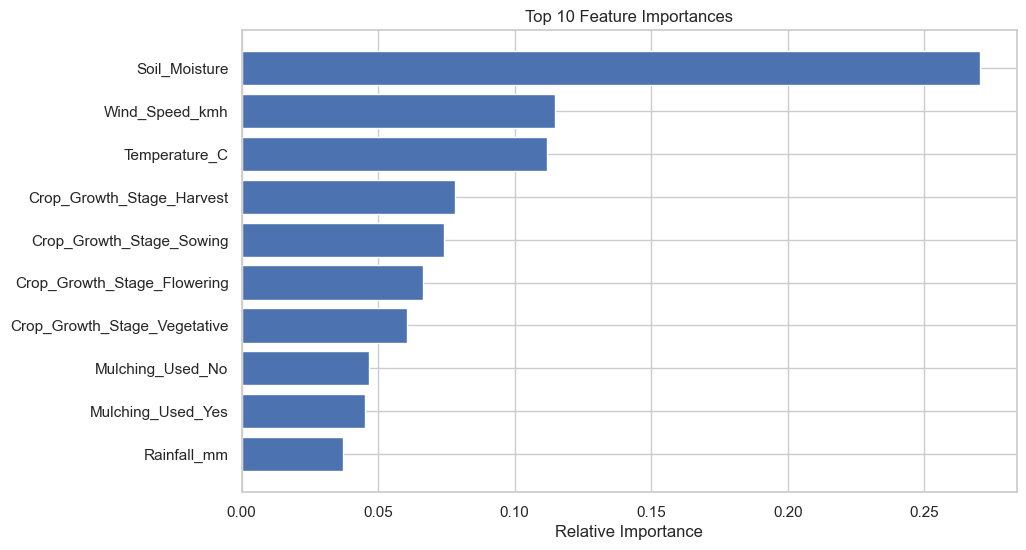

In [36]:
import matplotlib.pyplot as plt

# Get feature names from the encoders
feature_names = num_df.columns.tolist() + list(enc.get_feature_names_out())

importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Top 10 Feature Importances')
plt.show()

In [37]:
# Predict on the test set
test_predictions = best_model.predict(X_test)

# Convert numerical labels back to original text (e.g., 'Yes'/'No')
test_labels = le.inverse_transform(test_predictions)

# Create submission DataFrame
submission = pd.DataFrame({
    'id': test_df['id'],
    'Irrigation_Need': test_labels
})

submission.to_csv('submission.csv', index=False)
print("Predictions saved to submission.csv")

Predictions saved to submission.csv
